# DS-02: Exploración y Análisis de Datos (EDA)

**Proyecto:** TechKnowledge API — Hackathon ONE Alura Latam × Oracle
**Objetivo:** Analizar el dataset de contenidos técnicos, revisar distribuciones y calidad de los datos, y aplicar limpieza de texto antes del modelado.

**Checklist cubierto en este notebook:**
- [x] Cargar dataset con pandas
- [x] Mostrar distribución de categorías (`value_counts`)
- [x] Detectar valores nulos o vacíos
- [x] Función de limpieza: lowercase, sin acentos, sin puntuación, sin números
- [x] Guardar texto limpio en nueva columna
- [x] Combinar `titulo` + `texto` para enriquecer representación


## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)


## 2. Cargar dataset con pandas

Cargamos el archivo `contenidos.csv`, que contiene el corpus de contenidos técnicos etiquetados por categoría.

In [2]:
df = pd.read_csv("../data/contenidos.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(10)


Dimensiones del dataset: 60 filas x 4 columnas


,id,titulo,texto,categoria
0,doc_001,Introduccion a Spring Boot,En este contenido se presentan los conceptos basicos para la creacion de APIs REST utilizando Ja...,Backend
1,doc_002,Autenticacion con JWT en Node.js,Aprende a implementar autenticacion segura utilizando JSON Web Tokens en aplicaciones backend co...,Backend
2,doc_003,Arquitectura de microservicios,"Diseño de sistemas backend basados en microservicios, comunicacion entre servicios mediante REST...",Backend
3,doc_004,APIs REST con Django,"Construccion de APIs REST utilizando Django REST Framework, serializers, vistas basadas en clase...",Backend
4,doc_005,Manejo de excepciones en Java,"Buenas practicas para el manejo de excepciones en aplicaciones backend Java, incluyendo excepcio...",Backend
5,doc_006,Introduccion a GraphQL,NaN,Backend
6,doc_007,Patrones de diseño en backend,"Aplicacion de patrones de diseño como Singleton, Factory y Repository en el desarrollo de aplica...",Backend
7,doc_008,Colas de mensajes con RabbitMQ,Implementacion de comunicacion asincrona entre servicios backend utilizando colas de mensajes co...,Backend
8,doc_009,Testing de APIs con Postman,"Estrategias para probar endpoints backend utilizando Postman, incluyendo pruebas automatizadas y...",Backend
9,doc_010,Seguridad en aplicaciones backend,Practicas de seguridad esenciales para proteger APIs backend contra ataques comunes como inyecci...,Backend


In [3]:
# Información general del DataFrame: tipos de datos y conteo de no-nulos por columna
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         60 non-null     str  
 1   titulo     59 non-null     str  
 2   texto      59 non-null     str  
 3   categoria  60 non-null     str  
dtypes: str(4)
memory usage: 2.0 KB


## 3. Distribución de categorías (`value_counts`)

Es fundamental revisar que el dataset esté balanceado entre categorías. Si una categoría tiene muchos más ejemplos que otra,
el modelo puede sesgarse hacia la clase mayoritaria.

In [4]:
conteo_categorias = df['categoria'].value_counts()
print(conteo_categorias)

porcentaje_categorias = df['categoria'].value_counts(normalize=True) * 100
print("\nDistribución porcentual:")
print(porcentaje_categorias.round(2))


categoria
Backend             10
Frontend            10
Data Engineering    10
Cloud               10
DevOps              10
Database            10
Name: count, dtype: int64

Distribución porcentual:
categoria
Backend             16.67
Frontend            16.67
Data Engineering    16.67
Cloud               16.67
DevOps              16.67
Database            16.67
Name: proportion, dtype: float64


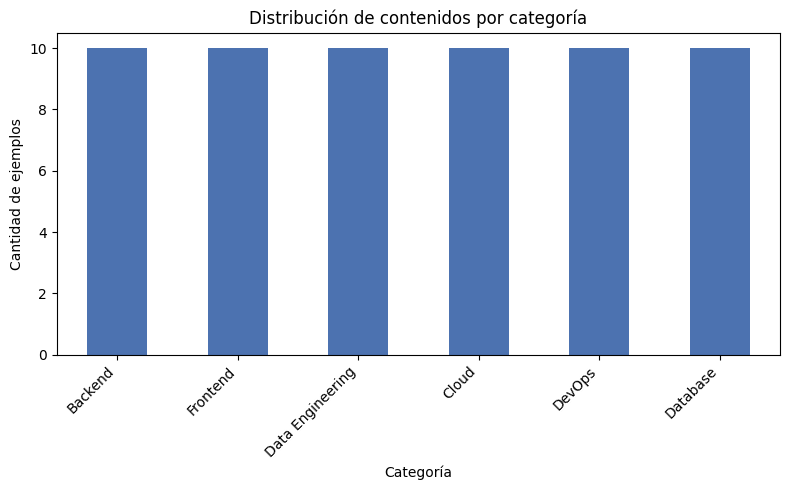

In [5]:
# Visualización de la distribución de categorías
plt.figure(figsize=(8, 5))
conteo_categorias.plot(kind='bar', color='#4C72B0')
plt.title('Distribución de contenidos por categoría')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de ejemplos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Interpretación:** si todas las barras tienen una altura similar, el dataset está balanceado y no es necesario aplicar
técnicas de balanceo (oversampling/undersampling) antes de entrenar el modelo.

## 4. Detectar valores nulos o vacíos

No solo revisamos `NaN` (nulos reales), sino también strings vacíos o que solo contienen espacios en blanco,
ya que estos últimos no los detecta `isnull()` pero igual representan datos faltantes.

In [6]:
# Valores nulos "clásicos" (NaN) por columna
print("Valores nulos (NaN) por columna:")
print(df.isnull().sum())


Valores nulos (NaN) por columna:
id           0
titulo       1
texto        1
categoria    0
dtype: int64


In [7]:
# Valores vacíos o solo espacios en blanco (no son NaN, pero equivalen a "sin dato")
def es_vacio_o_blanco(valor):
    if pd.isnull(valor):
        return True
    return str(valor).strip() == ""

for col in ['titulo', 'texto']:
    vacios = df[col].apply(es_vacio_o_blanco).sum()
    print(f"Columna '{col}': {vacios} valores nulos o vacíos")


Columna 'titulo': 1 valores nulos o vacíos
Columna 'texto': 1 valores nulos o vacíos


In [8]:
# Mostrar las filas problemáticas para inspección manual
filas_problematicas = df[
    df['titulo'].apply(es_vacio_o_blanco) | df['texto'].apply(es_vacio_o_blanco)
]
print(f"Total de filas con algún problema: {len(filas_problematicas)}")
filas_problematicas


Total de filas con algún problema: 2


,id,titulo,texto,categoria
5,doc_006,Introduccion a GraphQL,NaN,Backend
23,doc_024,NaN,Transformacion y modelado de datos analiticos utilizando dbt sobre almacenes de datos en la nube.,Data Engineering


In [9]:
# Decisión: eliminamos filas donde falte título o texto, ya que ambos son obligatorios
# para construir el corpus de entrenamiento (titulo + texto)
filas_antes = len(df)
df = df[~df['titulo'].apply(es_vacio_o_blanco) & ~df['texto'].apply(es_vacio_o_blanco)].reset_index(drop=True)
filas_despues = len(df)

print(f"Filas antes: {filas_antes}")
print(f"Filas después de eliminar nulos/vacíos: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")


Filas antes: 60
Filas después de eliminar nulos/vacíos: 58
Filas eliminadas: 2


In [10]:
# Verificamos que la distribución de categorías se mantenga razonablemente balanceada tras la limpieza
df['categoria'].value_counts()


categoria
Frontend            10
Cloud               10
DevOps              10
Database            10
Backend              9
Data Engineering     9
Name: count, dtype: int64

## 5. Función de limpieza de texto

Aplicamos los pasos estándar de limpieza para texto en español:
1. Convertir a minúsculas
2. Quitar acentos/tildes (normalización Unicode)
3. Quitar signos de puntuación
4. Quitar números
5. Quitar espacios múltiples sobrantes

Esto reduce la variabilidad del texto (ej: "Python" y "python" se tratan igual) y deja solo las palabras
que aportan significado real para la clasificación posterior.

In [11]:
def quitar_acentos(texto):
    """Normaliza caracteres unicode para eliminar tildes y diacríticos (á -> a, ñ se mantiene por ser letra propia del español... 
    nota: unicodedata NFD separa 'ñ' en 'n' + tilde también, así que aquí se pierde el carácter especial.
    Para este caso de uso (clasificación de texto técnico) es un trade-off aceptable."""
    nfkd = unicodedata.normalize('NFD', texto)
    return ''.join(c for c in nfkd if unicodedata.category(c) != 'Mn')


def limpiar_texto(texto):
    """Aplica el pipeline completo de limpieza de texto:
    minúsculas -> sin acentos -> sin puntuación -> sin números -> sin espacios extra.
    """
    if pd.isnull(texto):
        return ""

    texto = str(texto).lower()
    texto = quitar_acentos(texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)   # quita puntuación
    texto = re.sub(r'\d+', ' ', texto)         # quita números
    texto = re.sub(r'\s+', ' ', texto).strip() # espacios múltiples -> uno solo

    return texto


# Prueba rápida de la función con un ejemplo del dataset
ejemplo = df.loc[0, 'texto']
print("ANTES:")
print(ejemplo)
print("\nDESPUÉS:")
print(limpiar_texto(ejemplo))


ANTES:
En este contenido se presentan los conceptos basicos para la creacion de APIs REST utilizando Java y Spring Boot, incluyendo manejo de rutas, controladores y conexion a bases de datos.

DESPUÉS:
en este contenido se presentan los conceptos basicos para la creacion de apis rest utilizando java y spring boot incluyendo manejo de rutas controladores y conexion a bases de datos


## 6. Guardar texto limpio en una nueva columna

Aplicamos la función de limpieza a `titulo` y `texto`, guardando los resultados en nuevas columnas
(`titulo_limpio`, `texto_limpio`) para conservar siempre los datos originales sin modificar.

In [12]:
df['titulo_limpio'] = df['titulo'].apply(limpiar_texto)
df['texto_limpio'] = df['texto'].apply(limpiar_texto)

df[['titulo', 'titulo_limpio', 'texto', 'texto_limpio']].head(5)


,titulo,titulo_limpio,texto,texto_limpio
0,Introduccion a Spring Boot,introduccion a spring boot,En este contenido se presentan los conceptos basicos para la creacion de APIs REST utilizando Ja...,en este contenido se presentan los conceptos basicos para la creacion de apis rest utilizando ja...
1,Autenticacion con JWT en Node.js,autenticacion con jwt en node js,Aprende a implementar autenticacion segura utilizando JSON Web Tokens en aplicaciones backend co...,aprende a implementar autenticacion segura utilizando json web tokens en aplicaciones backend co...
2,Arquitectura de microservicios,arquitectura de microservicios,"Diseño de sistemas backend basados en microservicios, comunicacion entre servicios mediante REST...",diseno de sistemas backend basados en microservicios comunicacion entre servicios mediante rest ...
3,APIs REST con Django,apis rest con django,"Construccion de APIs REST utilizando Django REST Framework, serializers, vistas basadas en clase...",construccion de apis rest utilizando django rest framework serializers vistas basadas en clases ...
4,Manejo de excepciones en Java,manejo de excepciones en java,"Buenas practicas para el manejo de excepciones en aplicaciones backend Java, incluyendo excepcio...",buenas practicas para el manejo de excepciones en aplicaciones backend java incluyendo excepcion...


## 7. Combinar `titulo` + `texto` para enriquecer la representación

El título suele contener palabras clave muy relevantes para la categoría (ej: "Spring Boot", "React", "Kubernetes"),
así que lo combinamos con el texto limpio para formar el corpus final que alimentará al vectorizador TF-IDF.

In [13]:
df['corpus'] = df['titulo_limpio'] + ' ' + df['texto_limpio']

df[['titulo_limpio', 'texto_limpio', 'corpus']].head(5)


,titulo_limpio,texto_limpio,corpus
0,introduccion a spring boot,en este contenido se presentan los conceptos basicos para la creacion de apis rest utilizando ja...,introduccion a spring boot en este contenido se presentan los conceptos basicos para la creacion...
1,autenticacion con jwt en node js,aprende a implementar autenticacion segura utilizando json web tokens en aplicaciones backend co...,autenticacion con jwt en node js aprende a implementar autenticacion segura utilizando json web ...
2,arquitectura de microservicios,diseno de sistemas backend basados en microservicios comunicacion entre servicios mediante rest ...,arquitectura de microservicios diseno de sistemas backend basados en microservicios comunicacion...
3,apis rest con django,construccion de apis rest utilizando django rest framework serializers vistas basadas en clases ...,apis rest con django construccion de apis rest utilizando django rest framework serializers vist...
4,manejo de excepciones en java,buenas practicas para el manejo de excepciones en aplicaciones backend java incluyendo excepcion...,manejo de excepciones en java buenas practicas para el manejo de excepciones en aplicaciones bac...


In [14]:
# Longitud del corpus (en palabras) por fila — útil para detectar textos demasiado cortos
df['longitud_corpus'] = df['corpus'].apply(lambda x: len(x.split()))

print(df['longitud_corpus'].describe())


count    58.000000
mean     19.827586
std       3.377625
min      15.000000
25%      18.000000
50%      19.000000
75%      21.750000
max      34.000000
Name: longitud_corpus, dtype: float64


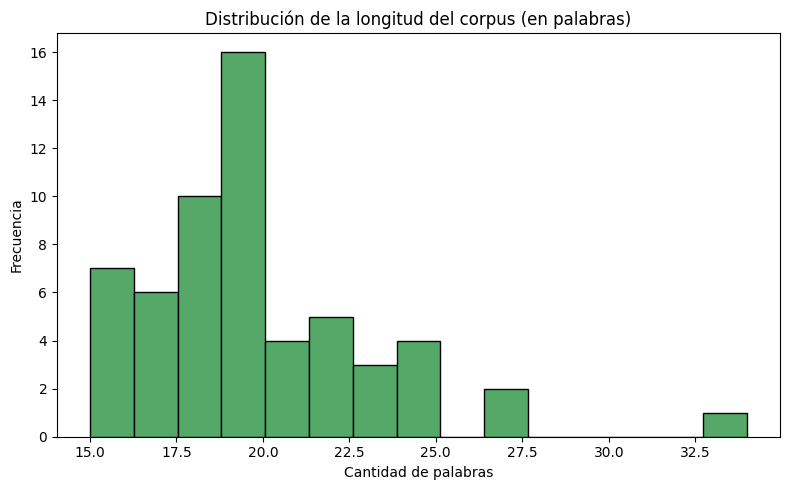

In [15]:
plt.figure(figsize=(8, 5))
df['longitud_corpus'].plot(kind='hist', bins=15, color='#55A868', edgecolor='black')
plt.title('Distribución de la longitud del corpus (en palabras)')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


**Interpretación:** si hay textos con muy pocas palabras (ej: menos de 5), conviene revisarlos manualmente —
podrían no aportar suficiente información para que el modelo aprenda el patrón de esa categoría.

## 8. Guardar dataset limpio

Guardamos el dataset ya procesado para que el siguiente notebook (entrenamiento del modelo) lo use directamente,
sin tener que repetir el proceso de limpieza.

In [16]:
df.to_csv("../data/contenidos_limpio.csv", index=False, encoding="utf-8")
print("Dataset limpio guardado en: data/contenidos_limpio.csv")
print(f"Dimensiones finales: {df.shape}")


Dataset limpio guardado en: data/contenidos_limpio.csv
Dimensiones finales: (58, 8)


## 9. Resumen del EDA

- El dataset cuenta con **60 ejemplos** distribuidos en **6 categorías** (Backend, Frontend, Data Engineering, Cloud, DevOps, Database), balanceado 10 ejemplos por clase.
- Se detectaron y eliminaron filas con título o texto nulo/vacío antes de continuar.
- Se aplicó limpieza estándar de texto (minúsculas, sin acentos, sin puntuación, sin números).
- Se generó la columna `corpus` (título + texto limpio) que será la entrada para la vectorización TF-IDF en el siguiente notebook.

**Siguiente paso:** `02_vectorizacion_modelo.ipynb` — Vectorización TF-IDF + entrenamiento de Regresión Logística.
